# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.plot import Plot

# frank1d
from frank.utilities import UVDataBinner

In [5]:
# frank1d
import frank
from frank.geometry import  SourceGeometry
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner

## Functions

In [6]:
from matplotlib.ticker import FuncFormatter

def sci_notation(x, pos):
    s = f"{x:.0e}"
    mantissa, exp = s.split('e')
    exp = int(exp)
    return rf"{mantissa}×10$^{{{exp}}}$" 

def float_notation(x, pos):
    s = f"{x:.0f}"
    return s

In [7]:
def calculate_resolution( clean_beam, intrinsic_resolution):
    bmaj_as = clean_beam['bmaj']
    bmin_as = clean_beam['bmin']
    final_bmaj_as = np.sqrt(bmaj_as**2 - intrinsic_resolution**2)
    final_bmin_as = np.sqrt(bmin_as**2 - intrinsic_resolution**2)
    print(f"-> Final beam to convolve with: {final_bmaj_as} x {final_bmin_as} arcsec")
    final_resolution = {'bmaj': final_bmaj_as, 'bmin': final_bmin_as, 'beam_pa': clean_beam['beam_pa']}
    return final_resolution

In [8]:
def edges(x):
    mids = (x[1:] + x[:-1]) / 2.0
    first = x[0]  - (x[1] - x[0]) / 2.0
    last  = x[-1] + (x[-1] - x[-2]) / 2.0
    return np.r_[first, mids, last]


In [9]:
def get_profile( x1, x2, f, bins, weighted = False, weights = None, fit_1d = False):
    from scipy.stats import binned_statistic
    
    if not fit_1d:
        r = np.hypot(x1, x2)
        r = r.ravel(order = 'C')
        f = f.ravel(order = 'C')
    else:
        r = x1

    if weighted:
        if weights is None:
            raise ValueError("Add weights.")
        F_W_binned, bin_edges, _ = binned_statistic(r, f*weights, 'sum', bins = bins)
        Weights_binned, bin_edges, _ = binned_statistic(r, weights, 'sum', bins = bins)

        f_1d = np.nan_to_num(F_W_binned, nan=0)
        f_1d = f_1d/Weights_binned
    else:
        f_1d, bin_edges, _ = binned_statistic(r, f, 'mean', bins = bins)
    
    r_1d = (bin_edges[:-1] + bin_edges[1:]) / 2
        
    return r_1d, f_1d

## Load data

In [10]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [11]:
data = AS209

# UVtable
dir = "../../data/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

In [12]:
# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

In [13]:
rout

2.4

In [14]:
np.hypot(u, v).min()

11458.93439803405

In [15]:
N = 1100

In [16]:
geom_f2d = Geometry(inc, pa, dra, ddec)

In [17]:
frank2d = Frank2D(N, rout)

In [18]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

In [19]:
best = {'m': -1.3620942401288272, 'c': 4681.245509195992, 'l': 72454.18892316935}

## Frank2D

In [20]:
frank2d.process_vis(uvtable)

===>  Setting gridded data...


In [21]:
q_min_f2d = np.unique(np.sort(np.hypot(frank2d.u, frank2d.v)))[1]
q_max_f2d = np.unique(np.sort(np.hypot(frank2d.u, frank2d.v)))[-1]

In [22]:
start_time = time.time()

frank2d.fit(kernel_params = best, rtol = 1e-10 )

end_time = time.time()
print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = {N} took {end_time - start_time} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")

===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.3620942401288272, 'c': 4681.245509195992, 'l': 72454.18892316935}
===>  Creating sparse linear system...
        +  Kernel = 0.05  min |  3.06 seconds
        +  Building system = 0.05  min |  3.14 seconds
===>  Solving linear system...
      .... iteration  0 :   actual tol  2.88e+08  versus  2.88e-02
      .... iteration  10 :   actual tol  1.28e+07  versus  2.88e-02
      .... iteration  20 :   actual tol  6.83e+06  versus  2.88e-02
      .... iteration  30 :   actual tol  3.50e+06  versus  2.88e-02
      .... iteration  40 :   actual tol  2.91e+06  versus  2.88e-02
      .... iteration  50 :   actual tol  4.89e+05  versus  2.88e-02
      .... iteration  60 :   actual tol  2.35e+05  versus  2.88e-02
      .... iteration  70 :   actual tol  7.53e+04  versus  2.88e-02
      .... iteration  80 :   actual tol  6.30e+04  versus  2.88e-02
      .... iteration  90 :   actual tol  2.68e+05  versus  2.88e-02
      .... it

      .... iteration  130 :   actual tol  2.55e+03  versus  2.88e-02
      .... iteration  140 :   actual tol  1.16e+03  versus  2.88e-02
      .... iteration  150 :   actual tol  3.57e+02  versus  2.88e-02
      .... iteration  160 :   actual tol  2.33e+02  versus  2.88e-02
      .... iteration  170 :   actual tol  1.17e+02  versus  2.88e-02
      .... iteration  180 :   actual tol  3.09e+01  versus  2.88e-02
      .... iteration  190 :   actual tol  6.30e+01  versus  2.88e-02
      .... iteration  200 :   actual tol  1.44e+01  versus  2.88e-02
      .... iteration  210 :   actual tol  4.34e+00  versus  2.88e-02
      .... iteration  220 :   actual tol  4.51e+00  versus  2.88e-02
      .... iteration  230 :   actual tol  2.25e+00  versus  2.88e-02
      .... iteration  240 :   actual tol  1.66e+00  versus  2.88e-02
      .... iteration  250 :   actual tol  1.13e+00  versus  2.88e-02
      .... iteration  260 :   actual tol  6.27e-01  versus  2.88e-02
      .... iteration  270 :   actu

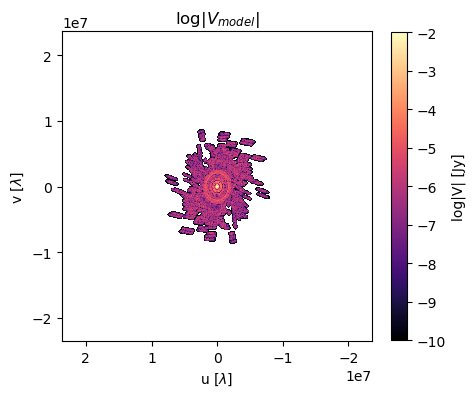

In [24]:
Plot(frank2d, geom_f2d).visibility(kind='model', fig_size = 5, title = r'log|$V_{model}$|')

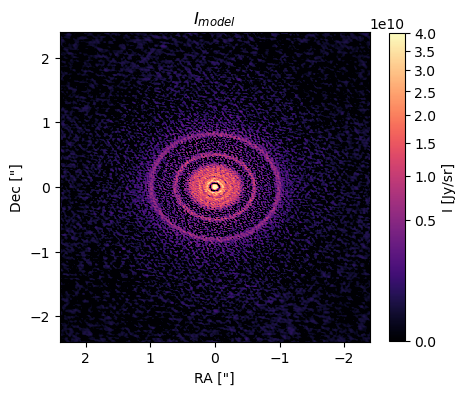

In [25]:
Plot(frank2d, geom_f2d).intensity(fig_size = 5, title = r'$I_{model}$')

## Frank1D

In [26]:
u_f1d, v_f1d =  uvtable['u'], uvtable['v']
vis_f1d = uvtable['vis']
weights_f1d = uvtable['weights']

In [28]:
# Frank 1D parameters
#n_pts = 1100
#alpha = 1.05
#w_smooth = 1e-4
#r_out = 2.4

#geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
#FF = FrankFitter(r_out, n_pts, geom, alpha = alpha, weights_smooth = w_smooth)
#sol = FF.fit(u_f1d, v_f1d, vis_f1d, weights_f1d)


import pickle

path_f1d = dir +"f1d_AS209_N1100_a1p05_w1em4_r2p4.pkl"

# Abrir y cargar el objeto
with open(path_f1d, 'rb') as f:   # 'rb' = read binary
    f1d = pickle.load(f)

In [29]:
#save object
#import pickle
#with open("f1d_N1100_a1p05_w1em4_r2p4.pkl", "wb") as file:
#    pickle.dump(sol_f1d, file)

## CLEAN MODEL

In [60]:

dir_  = "../../data/"
disk_name = data['disk_name']
data_file = dir_ +"CLEAN_model_" + disk_name + "_continuum.npz"

# Load data
file = np.load(data_file)
u_c, v_c, Re_c, Im_c, Weights_c = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis_c = Re_c + Im_c*1j

In [61]:
# clean model
u_model_c = u_c
v_model_c = v_c
vis_model_c = Vis_c
weights_model_c = Weights_c

In [62]:
uvtable_clean = {'u': u_model_c, 'v': v_model_c, 'vis': vis_model_c, 'weights': weights_model_c}

# Vis space


## 1D
* We use the full uvtable to make the profile.
* There is no convolution here!


In [63]:
f2d = frank2d
geom = geom_f2d

In [64]:
u_input = uvtable['u']
v_input = uvtable['v']
vis_input = uvtable['vis']
weights_input = uvtable['weights']

u_model_1d_f2d = f2d.u
v_model_1d_f2d = f2d.v

In [65]:
# f2d model
u_model_f2d = f2d.u_grid
v_model_f2d = f2d.v_grid
vis_model_f2d = f2d.visibility_model

# phase_shift
# is necessary to be done in the East of North convention.
vis_input = geom.apply_phase_shift(-u_input, -v_input, vis_input)
vis_model_f2d = geom.apply_phase_shift(-u_model_f2d, -v_model_f2d, vis_model_f2d)
vis_model_c = geom.apply_phase_shift(-u_model_c, -v_model_c, vis_model_c)
    
# deproject
u_model_f2d, v_model_f2d, _ = geom.deproject(u_model_f2d, v_model_f2d)
u_model_1d_f2d, v_model_1d_f2d, _ = geom.deproject(u_model_1d_f2d, v_model_1d_f2d)
u_input, v_input, _ = geom.deproject(u_input, v_input)
u_model_c, v_model_c, _ = geom.deproject(u_model_c, v_model_c)


# collocation points for the plot.
q = np.unique(np.hypot(u_model_1d_f2d, v_model_1d_f2d))
q = np.sort(q)
bins = 2*N
q = np.linspace(q[0], q[-1], bins)
edges_ = edges(q)           

In [66]:
vis_model_f1d = f1d.predict_deprojected(q = q)

In [67]:
bins

2200

In [68]:
np.hypot(u_model_c, v_model_c)/1e4

array([ 17.88243132,  15.68791488,  25.52200401, ..., 129.40887189,
       158.71908178, 138.35082281])

In [113]:
# ----------------
baselines = np.hypot(u_input, v_input)         
grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                            np.log10(max(baselines.max(), baselines[-1])),
                            10**4)

bin_widths = [1e3, 5e4, 1e5]

binned_vis0 = UVDataBinner(baselines, vis_input, weights_input , bin_widths[0])
binned_vis1 = UVDataBinner(baselines, vis_input, weights_input, bin_widths[1])
binned_vis2 = UVDataBinner(baselines, vis_input, weights_input, bin_widths[2])


# ----------------
                         

In [70]:
q_model_1d_f2d, vis_model_1d_f2d = get_profile(u_model_f2d, v_model_f2d, vis_model_f2d,
                                            bins = edges_,
                                            weighted = False, weights = frank2d.gridded_data['weights'])

#vis_model_1d_f2d = np.nan_to_num(vis_model_1d_f2d, nan=0)


In [71]:

q_model_1d_c, vis_model_1d_c = get_profile(u_model_c, v_model_c, vis_model_c,
                                                bins = edges_,
                                                weighted = False, weights = weights_model_c)

#vis_model_1d_c = np.nan_to_num(vis_model_1d_c, nan=0)

In [72]:
q_model_1d_data, vis_model_1d_data = get_profile(u_input, v_input, vis_input,
                                                bins = edges_,
                                                weighted = False, weights = weights_input)

In [73]:
cs = ['#c9cad9', 'black']
ms =  ['o', 'x', '.']

### Exploratory plots

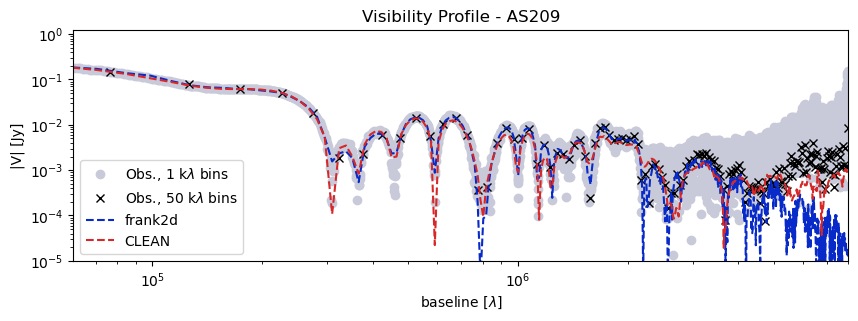

In [74]:
plt.figure(figsize=(10,3))
# Raw visibilities ---------------------------------------------------------

plt.plot(binned_vis0.uv, np.abs(binned_vis0.V), c=cs[0],
                marker=ms[0], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

plt.plot(binned_vis1.uv, np.abs(binned_vis1.V), c=cs[1],
                marker=ms[1], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

#plt.plot(binned_vis2.uv, np.abs(binned_vis2.V), c='green',
#                marker=ms[2], ls='None', 
#                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[2]/1e3))

# frank2D -------------------------------------------------------------------
plt.plot(q, np.abs(vis_model_1d_f2d), color = '#072ac8', ls ='--', label = r'frank2d')

# CLEAN ---------------------------------------------------------------------
plt.plot(q, np.abs(vis_model_1d_c), color = '#d62828', ls ='--', label = r'CLEAN')

plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-5, 0)
plt.xlim(q_min_f2d, 8e6)
plt.title(f'Visibility Profile - {disk_name}')
plt.ylabel('|V| [Jy]', size = 10)
plt.legend(fontsize= 10, loc = 'best')
plt.show()

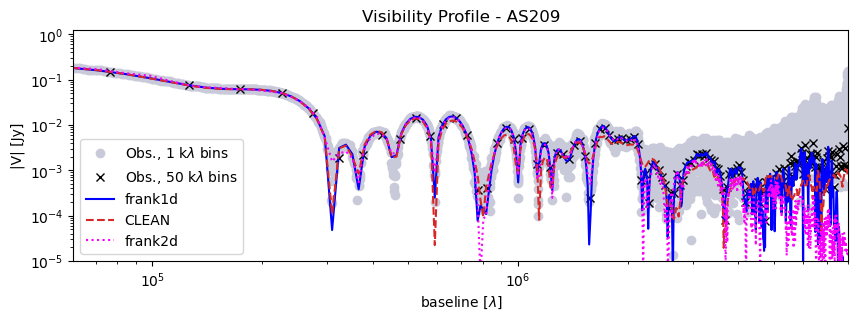

In [75]:
plt.figure(figsize=(10,3))
# Raw visibilities ---------------------------------------------------------

plt.plot(binned_vis0.uv, np.abs(binned_vis0.V), c=cs[0],
                marker=ms[0], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

plt.plot(binned_vis1.uv, np.abs(binned_vis1.V), c=cs[1],
                marker=ms[1], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

#plt.plot(binned_vis2.uv, np.abs(binned_vis2.V), c='green',
#                marker=ms[2], ls='None', 
#                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[2]/1e3))

# frank1d ---------------------------------------------------------------------
plt.plot(q, np.abs(vis_model_f1d), color = 'blue', ls ='-', label = r'frank1d')


# CLEAN ---------------------------------------------------------------------
plt.plot(q, np.abs(vis_model_1d_c), color = '#d62828', ls ='--', label = r'CLEAN')

# frank2D -------------------------------------------------------------------
plt.plot(q, np.abs(vis_model_1d_f2d), color = '#FA00FA', ls =':', label = r'frank2d')


plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-5, 0)
plt.xlim(q_min_f2d, 8e6)
plt.title(f'Visibility Profile - {disk_name}')
plt.ylabel('|V| [Jy]', size = 10)
plt.legend(fontsize= 10, loc = 'best')
plt.show()

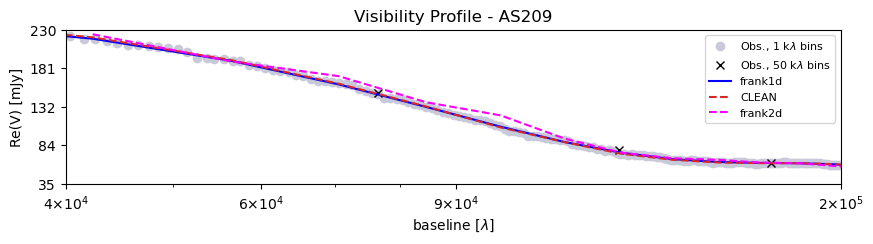

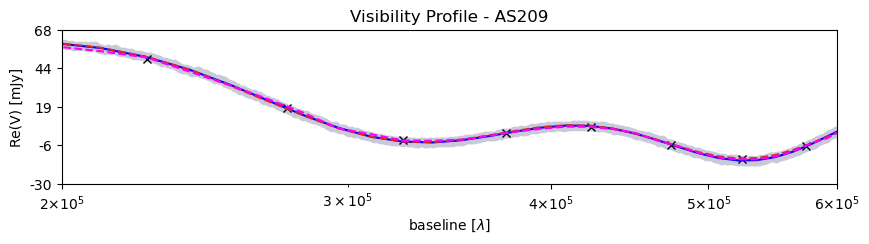

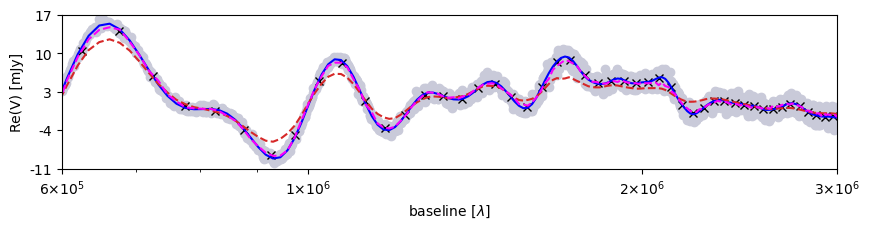

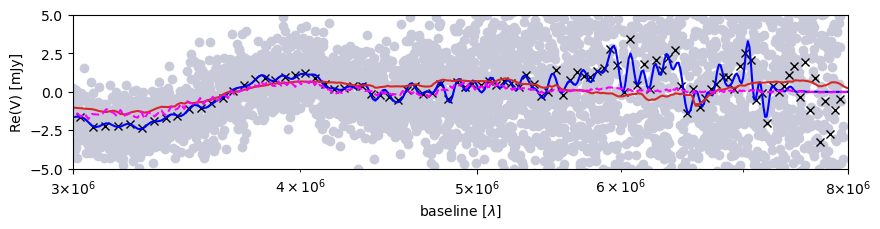

In [85]:
plt.figure(figsize=(10,2))
# Raw visibilities ---------------------------------------------------------

plt.plot(binned_vis0.uv, binned_vis0.V.real*1e3, c=cs[0],
                marker=ms[0], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

plt.plot(binned_vis1.uv, binned_vis1.V.real*1e3, c=cs[1],
                marker=ms[1], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

# frank1d ---------------------------------------------------------------------
plt.plot(q, vis_model_f1d.real*1e3, color = 'blue', ls ='-', label = r'frank1d')

# CLEAN ---------------------------------------------------------------------
plt.plot(q, vis_model_1d_c.real*1e3, color = '#d62828', ls ='--', label = r'CLEAN')

# frank2D -------------------------------------------------------------------
plt.plot(q, vis_model_1d_f2d.real*1e3, color = '#FA00FA', ls ='--', label = r'frank2d')

plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
y_lim_1 = (35, 230)
x_lim_1 = (4e4, 2e5)
plt.ylim(y_lim_1)
plt.xlim(x_lim_1)
plt.ylabel('Re(V) [mJy]', size = 10)
plt.title(f'Visibility Profile - {disk_name}')
plt.legend(fontsize = 8, loc = 'best')


plt.xticks([4e4, 6e4, 9e4, 2e5])
plt.yticks(np.linspace(y_lim_1[0], y_lim_1[1], 5))
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(sci_notation))
ax.yaxis.set_major_formatter(FuncFormatter(float_notation))

plt.show()

#---------------------------------------------------------------------------

plt.figure(figsize=(10,2))
# Raw visibilities ---------------------------------------------------------

plt.plot(binned_vis0.uv, binned_vis0.V.real*1e3, c=cs[0],
                marker=ms[0], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

plt.plot(binned_vis1.uv, binned_vis1.V.real*1e3, c=cs[1],
                marker=ms[1], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

# frank1d ---------------------------------------------------------------------
plt.plot(q, vis_model_f1d.real*1e3, color = 'blue', ls ='-', label = r'frank1d')

# CLEAN ---------------------------------------------------------------------
plt.plot(q, vis_model_1d_c.real*1e3, color = '#d62828', ls ='--', label = r'CLEAN')

# frank2D -------------------------------------------------------------------
plt.plot(q, vis_model_1d_f2d.real*1e3, color = '#FA00FA', ls ='--', label = r'frank2d')

plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
y_lim_1 = (-30, 68)
x_lim_1 = (2e5, 6e5)
plt.ylim(y_lim_1)
plt.xlim(x_lim_1)
plt.ylabel('Re(V) [mJy]', size = 10)
plt.title(f'Visibility Profile - {disk_name}')
#plt.legend(fontsize = 8, loc = 'best')


plt.xticks([2e5, 4e5, 5e5, 6e5])
plt.yticks(np.linspace(y_lim_1[0], y_lim_1[1], 5))
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(sci_notation))
ax.yaxis.set_major_formatter(FuncFormatter(float_notation))

plt.show()

#---------------------------------------------------------------------------

plt.figure(figsize=(10,2))
# Raw visibilities ---------------------------------------------------------

plt.plot(binned_vis0.uv, binned_vis0.V.real*1e3, c=cs[0],
                marker=ms[0], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

plt.plot(binned_vis1.uv, binned_vis1.V.real*1e3, c=cs[1],
                marker=ms[1], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


# frank1d ---------------------------------------------------------------------
plt.plot(q, vis_model_f1d.real*1e3, color = 'blue', ls ='-', label = r'frank1d')

# CLEAN ---------------------------------------------------------------------
plt.plot(q, vis_model_1d_c.real*1e3, color = '#d62828', ls ='--', label = r'CLEAN')

# frank2D -------------------------------------------------------------------
plt.plot(q, vis_model_1d_f2d.real*1e3, color = '#FA00FA', ls ='--', label = r'frank2d')


plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
y_lim_2 = (-11, 17)
plt.ylim(y_lim_2)
x_lim_2 = (6e5, 3e6)
plt.xlim(x_lim_2)
plt.ylabel('Re(V) [mJy]', size = 10)
#plt.legend(fontsize = 6, loc = 'best')


plt.xticks([6e5, 1e6, 2e6, 3e6])
plt.yticks(np.linspace(y_lim_2[0], y_lim_2[1], 5))
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(sci_notation))
ax.yaxis.set_major_formatter(FuncFormatter(float_notation))

plt.show()

#---------------------------------------------------------------------------
plt.figure(figsize=(10,2))
# Raw visibilities ---------------------------------------------------------

plt.plot(binned_vis0.uv, binned_vis0.V.real*1e3, c=cs[0],
                marker=ms[0], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

plt.plot(binned_vis1.uv, binned_vis1.V.real*1e3, c=cs[1],
                marker=ms[1], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


# frank1d ---------------------------------------------------------------------
plt.plot(q, vis_model_f1d.real*1e3, color = 'blue', ls ='-', label = r'frank1d')

# CLEAN ---------------------------------------------------------------------
plt.plot(q, vis_model_1d_c.real*1e3, color = '#d62828', ls ='-', label = r'CLEAN')

# frank2D -------------------------------------------------------------------
plt.plot(q, vis_model_1d_f2d.real*1e3, color = '#FA00FA', ls ='--', label = r'frank2d')


plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
y_lim_3 = (-5, 5)
x_lim_3 = (3e6, 8e6)
plt.ylim(y_lim_3)
plt.xlim(x_lim_3)
plt.ylabel('Re(V) [mJy]', size = 10)
#plt.legend(fontsize = 6, loc = 'best')

plt.xticks([3e6, 5e6, 8e6])
plt.yticks(np.linspace(y_lim_3[0], y_lim_3[1], 5))
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(sci_notation))

plt.show()


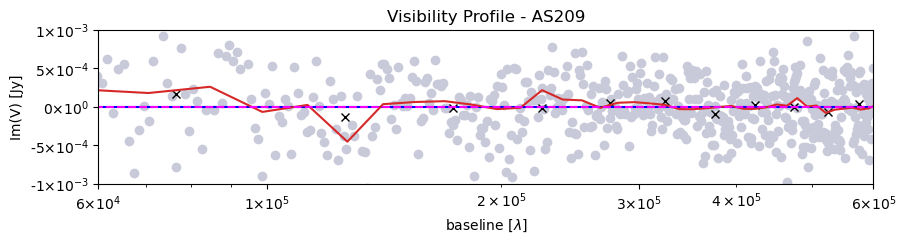

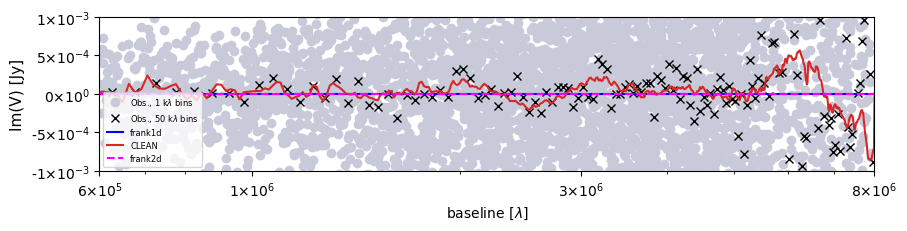

In [77]:
plt.figure(figsize=(10,2))
# Raw visibilities ---------------------------------------------------------

plt.plot(binned_vis0.uv, binned_vis0.V.imag, c=cs[0],
                marker=ms[0], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

plt.plot(binned_vis1.uv, binned_vis1.V.imag, c=cs[1],
                marker=ms[1], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


# frank1d ---------------------------------------------------------------------
plt.plot(q, vis_model_f1d.imag, color = 'blue', ls ='-', label = r'frank1d')

# CLEAN ---------------------------------------------------------------------
plt.plot(q, vis_model_1d_c.imag, color = '#d62828', ls ='-', label = r'CLEAN')

# frank2D -------------------------------------------------------------------
plt.plot(q, vis_model_1d_f2d.imag, color = '#FA00FA', ls ='--', label = r'frank2d')

plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.ylim(-11e-3, 17)
plt.xlim(q_min_f2d, 6e5)
plt.ylabel('Im(V) [Jy]', size = 10)
plt.title(f'Visibility Profile - {disk_name}')
#plt.legend(fontsize = 7, loc = 'best')

plt.xticks([q_min_f2d, 1e5, 3e5, 6e5])
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(sci_notation))
ax.xaxis.set_major_formatter(FuncFormatter(sci_notation))


plt.show()



plt.figure(figsize=(10,2))
# Raw visibilities ---------------------------------------------------------

plt.plot(binned_vis0.uv, binned_vis0.V.imag, c=cs[0],
                marker=ms[0], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

plt.plot(binned_vis1.uv, binned_vis1.V.imag, c=cs[1],
                marker=ms[1], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


# frank1d ---------------------------------------------------------------------
plt.plot(q, vis_model_f1d.imag, color = 'blue', ls ='-', label = r'frank1d')

# CLEAN ---------------------------------------------------------------------
plt.plot(q, vis_model_1d_c.imag, color = '#d62828', ls ='-', label = r'CLEAN')

# frank2D -------------------------------------------------------------------
plt.plot(q, vis_model_1d_f2d.imag, color = '#FA00FA', ls ='--', label = r'frank2d')

plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.ylim(-0.001, 0.001)
plt.xlim(6e5, 8e6)
plt.ylabel('Im(V) [Jy]', size = 11)
#plt.title(f'Visibility Profile - {disk_name}')
plt.legend(fontsize = 6, loc = 'best')
plt.xticks([6e5, 1e6, 3e6, 8e6])
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(sci_notation))
ax.xaxis.set_major_formatter(FuncFormatter(sci_notation))


plt.show()

### Official plots

In [216]:
def run_plot(binning, x_lims = (1e5,8e6), y_lims_re = (-11, 17), y_lims_im = (-2, 2)):
    # Errors of visibilities
    binning = binning
    binning_re = binning.V.real*1e3
    binning_im = binning.V.imag*1e3
    binning_uv = binning.uv
    binning_re_err = binning.error.real*1e3
    binning_im_err = binning.error.imag*1e3

    x_lims = x_lims
    y_lims_re = y_lims_re
    y_lims_im = y_lims_im

    target_label = disk_name

    #Plot data
    fig, axs = plt.subplots(2,1,figsize=(12,5), gridspec_kw={'height_ratios': [3, 1]})
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0, hspace=0.05)

    #axs[0].plot(binned_vis0.uv, binned_vis0.V.real*1e3, c=cs[0], marker=ms[0], ls='None', alpha=0.5,
    #                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
    axs[0].errorbar(binning_uv, binning_re, binning_re_err, color='gray',fmt='x', alpha=0.7, capsize=2, linewidth=1, zorder=1, label='Data')
    #axs[0].plot(binning_uv / 1e6, vis_fit, color='r', linewidth=2, zorder=1.5, label='frank fit')
    axs[0].text(0.96, 0.88, target_label, ha='right', transform=axs[0].transAxes, fontsize=25)
    axs[0].plot(q, vis_model_1d_f2d.real*1e3, color = '#FA00FA', ls ='--', label = r'frank2d')
    axs[0].set_xscale('log')

    axs[1].errorbar(binning_uv, binning_im, binning_im_err, color='grey', fmt='x', alpha=0.7, capsize=2, linewidth=1, zorder=1)
    axs[1].plot(binning_uv, np.zeros(binning_uv.shape[0]), color='r', linestyle='dashed', zorder=1.5, linewidth=2)
    axs[1].plot(q, vis_model_1d_f2d.imag*1e3, color = '#FA00FA', ls ='--', label = r'frank2d')
    axs[1].set_xscale('log')

    axs[0].hlines(0,-10,10, alpha=1, linestyle=(0,(1,5)), color='k', linewidth=1, zorder=0)
    axs[1].hlines(0,-10,10, alpha=1, linestyle=(0,(1,5)), color='k', linewidth=1, zorder=0)


    axs[0].set_xlim(x_lims)
    axs[1].set_xlim(x_lims)
    axs[0].set_ylim(y_lims_re)
    axs[1].set_ylim(y_lims_im)

    axs[0].tick_params(which='major',axis='both',right=True,top=True, labelsize=15, pad=10,width=2.5, length=5,direction='in',color='k')
    axs[0].tick_params(which='minor',axis='both',right=True,top=True, labelsize=15, pad=10,width=1.5, length=3,direction='in',color='k')

    axs[1].tick_params(which='major',axis='both',right=True,top=True, labelsize=15, pad=10,width=2.5, length=5,direction='in',color='k')
    axs[1].tick_params(which='minor',axis='both',right=True,top=True, labelsize=15, pad=10,width=1.5, length=3,direction='in',color='k')

    axs[0].set_xlabel(r'Deprojected baseline (M$\lambda$)', fontsize = 15, labelpad=10)
    axs[0].set_ylabel('Re(V) (mJy)', fontsize = 15, labelpad=10)

    axs[1].set_xlabel(r'Deprojected baseline (M$\lambda$)', fontsize = 15, labelpad=10)
    axs[1].set_ylabel('Im(V) (mJy)', fontsize = 15, labelpad=15)

    handles, labels = axs[0].get_legend_handles_labels()
    order = [1, 0]  # frank fit second (index 0), Data first (index 1)
    axs[0].legend([handles[idx] for idx in order],[labels[idx] for idx in order],
                bbox_to_anchor=[0.98, 0.9], fontsize=12)

    # Hide x labels and tick labels for top plots and y ticks for right plots.
    for ax in axs.flat:
        ax.label_outer()
    
    for axis in ['top', 'bottom', 'left', 'right']:
        axs[0].spines[axis].set_linewidth(2)    
        axs[1].spines[axis].set_linewidth(2) 

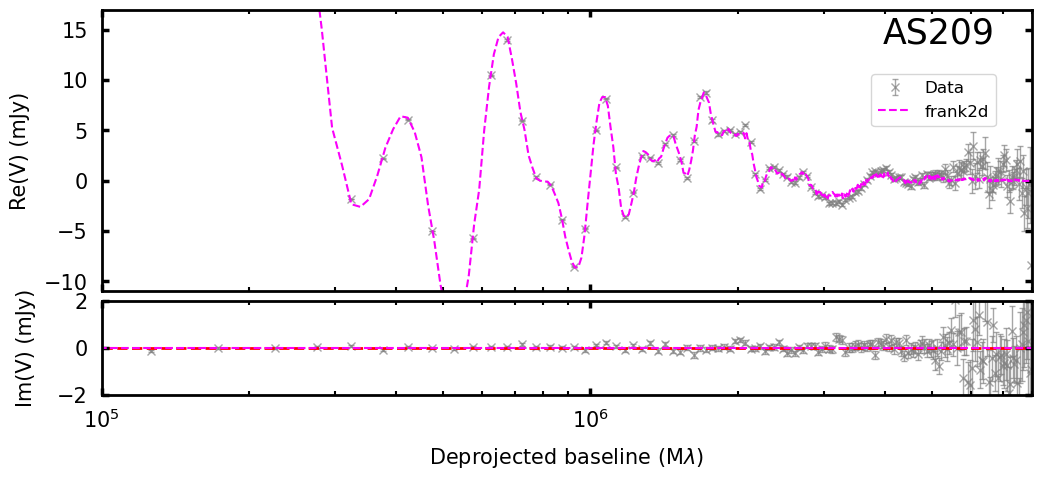

In [215]:
run_plot(binned_vis1)

In [244]:
sigma = np.abs(binned_vis1.error.data)*1e3

In [226]:
residual_f2d_clean = np.abs(vis_model_1d_f2d-vis_model_1d_c)*1e3

In [227]:
ground = vis_model_1d_data

In [228]:
residual_clean_data = np.abs(ground - vis_model_1d_c)*1e3

In [229]:
residual_f2d_data  =  np.abs(ground - vis_model_1d_f2d)*1e3

In [230]:
q_max = 5e6
def rmse(model, ground):
    residuals = model - ground
    # fit until certain baseline
    residuals = residuals[q_model_1d_data <= q_max]
    residuals = residuals[~np.isnan(residuals)]
    rmse_ = np.sqrt(np.mean(residuals**2))
    return rmse_

# RMSE
avg_residual_f2d_data = rmse(vis_model_1d_f2d, ground)
avg_residual_clean_data = rmse(vis_model_1d_c, ground)

In [231]:
avg_residual_f2d_data

(0.0011511920841326317+1.0785352194755552e-05j)

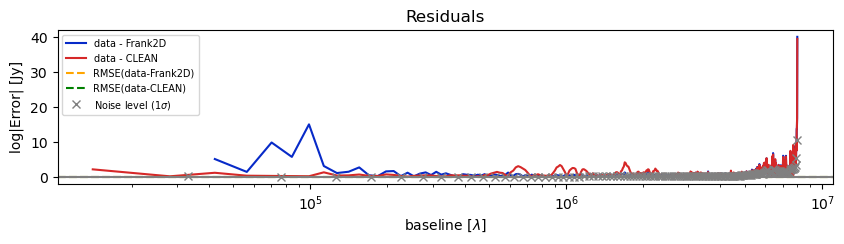

"\nplt.figure(figsize=(10,2))\n#plt.plot(q, np.abs(residual_f2d_clean), color = 'red', ls ='--', label = r' residual f2d-clean')\nplt.plot(q, residual_f2d_data.real, color = '#072ac8', ls ='-', label = r'data - f2d')\nplt.plot(q, residual_clean_data.real, color = '#d62828', ls ='-', label = r'data - clean')\nplt.axhline(avg_residual_f2d_data.real, color = 'orange', ls ='--', label = r'RMSE(data-clean)')\nplt.axhline(avg_residual_clean_data.real, color = 'green', ls ='--', label = r'RMSE(dar)')\nplt.axvline(q_max, color = 'black', ls =':', label = r'$q_{max} $ = ' + f'{q_max:.1e}$\\lambda$')\n#plt.axhline(0.0, color = 'gray', ls ='-')\nplt.xlabel(r'baseline [$\\lambda$]')\nplt.xscale('log')\n#plt.yscale('log')\nplt.ylim(-0.005, 0.005)\nplt.xlim(q_min_f2d, 8e6)\nplt.ylabel('Re(Error) [Jy]', size = 10)\nplt.show()\n\nplt.figure(figsize=(10,2))\n#plt.plot(q, np.abs(residual_f2d_clean), color = 'red', ls ='--', label = r' residual f2d-clean')\nplt.plot(q, residual_f2d_data.imag, color = '#0

In [251]:
plt.figure(figsize=(10,2))
#plt.plot(q, np.abs(residual_f2d_clean), color = 'red', ls ='--', label = r' residual f2d-clean')
plt.plot(q, residual_f2d_data, color = '#072ac8', ls ='-', label = r'data - Frank2D')
plt.plot(q, residual_clean_data, color = '#d62828', ls ='-', label = r'data - CLEAN')
plt.axhline(avg_residual_f2d_data, color = 'orange', ls ='--', label = r'RMSE(data-Frank2D)')
plt.axhline(avg_residual_clean_data, color = 'green', ls ='--', label = r'RMSE(data-CLEAN)')
plt.plot(binned_vis1.uv, sigma, color = 'gray', ls ='None', marker='x', label = r'Noise level (1$\sigma$)')
plt.xlabel(r'baseline [$\lambda$]')
#plt.axvline(q_max, color = 'black', ls =':', label = r'$q_{max} $ = ' + f'{q_max:.1e}$\lambda$')
plt.axhline(0.0, color = 'gray', ls ='-')
plt.xscale('log')
#plt.ylim(-0.001, 0.01)
#plt.yscale('log')
#plt.xlim(q_min_f2d, 8e6)
plt.ylabel('log|Error| [Jy]', size = 10)
plt.title('Residuals')
plt.legend(fontsize= 7, loc = 'best')
plt.show()

"""
plt.figure(figsize=(10,2))
#plt.plot(q, np.abs(residual_f2d_clean), color = 'red', ls ='--', label = r' residual f2d-clean')
plt.plot(q, residual_f2d_data.real, color = '#072ac8', ls ='-', label = r'data - f2d')
plt.plot(q, residual_clean_data.real, color = '#d62828', ls ='-', label = r'data - clean')
plt.axhline(avg_residual_f2d_data.real, color = 'orange', ls ='--', label = r'RMSE(data-clean)')
plt.axhline(avg_residual_clean_data.real, color = 'green', ls ='--', label = r'RMSE(dar)')
plt.axvline(q_max, color = 'black', ls =':', label = r'$q_{max} $ = ' + f'{q_max:.1e}$\lambda$')
#plt.axhline(0.0, color = 'gray', ls ='-')
plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
#plt.yscale('log')
plt.ylim(-0.005, 0.005)
plt.xlim(q_min_f2d, 8e6)
plt.ylabel('Re(Error) [Jy]', size = 10)
plt.show()

plt.figure(figsize=(10,2))
#plt.plot(q, np.abs(residual_f2d_clean), color = 'red', ls ='--', label = r' residual f2d-clean')
plt.plot(q, residual_f2d_data.imag, color = '#072ac8', ls ='-', label = r'f2d-data')
plt.plot(q, residual_clean_data.imag, color = '#d62828', ls ='-', label = r'clean-data')
#plt.axhline(0.0, color = 'gray', ls ='-')
plt.axhline(avg_residual_f2d_data.imag, color = 'orange', ls ='--', label = r'RMSE(f2d-data)')
plt.axhline(avg_residual_clean_data.imag, color = 'green', ls ='--', label = r'RMSE(clean-data)')
plt.xlabel(r'baseline [$\lambda$]')
plt.axvline(q_max, color = 'black', ls =':', label = r'$q_{max} $ = ' + f'{q_max:.1e}$\lambda$')
plt.xscale('log')
#plt.yscale('log')
plt.ylim(-0.0006, 0.0006)
plt.xlim(q_min_f2d, 8e6)
plt.ylabel('Im(Error) [Jy]', size = 10)
plt.show()
"""

## 2D


* We compare with FFT(CLEAN .model)
* By now, we'll use imsize = 3000, rout = 2,4 -> cellsize = 0.0016, but in the future we plan rout = 2,4 and imsize = 1600 -> REDO CLEAN!

In [55]:
imsize = 3000

In [56]:
rmax = rout
rmax


2.4

In [57]:
frank2d2 = Frank2D(imsize, rmax)

In [58]:
start_time = time.time()
frank2d2.fit(data = uvtable, kernel_params = best, rtol = 1e-8 )

end_time = time.time()
print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = {imsize} took {end_time - start_time} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.3620942401288272, 'c': 4681.245509195992, 'l': 72454.18892316935}
===>  Creating sparse linear system...
        + time kernel = 0.04  min |  2.52 seconds
        + Using preconditioner method:  jacobi
        + time building system = 0.04  min |  2.58 seconds
===>  Solving linear system...
         + maxiter =  50000  & rtol =  1e-08
         + final tolerance :  2.881752289367308
                        .... iteration:  0
                              -> actual tol  2.88e+08  versus  2.88e+00
                        .... iteration:  1
                              -> actual tol  2.63e+07  versus  2.88e+00
                        .... iteration:  2
                              -> actual tol  2.32e+07  versus  2.88e+00
                        .... iteration:  3
                              -> actual tol  2.32e+07  versus  2.88e+00
                        .... iteration:  4
           

In [59]:
cell =  2*rmax/imsize
cell

0.0015999999999999999

### Frank2d Vis Map

In [60]:
vis2d_f2d = frank2d2.visibility_model

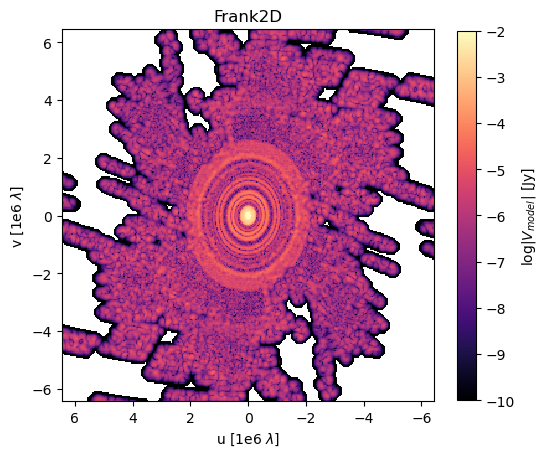

In [86]:
u_f2d, v_f2d = -frank2d2.u_grid.reshape(imsize,imsize), -frank2d2.v_grid.reshape(imsize,imsize)

plt.figure(figsize = (6, 6))
plt.pcolormesh( u_f2d/1e6, v_f2d/1e6,
                np.log(np.abs(vis2d_f2d.reshape(imsize,imsize))),
                cmap="magma",
                vmin=-10, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title("Frank2D")
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'log|$V_{model}$| [Jy]', size=10)
plt.xlim(u_f2d.max()/1e7, u_f2d.min()/1e7)
plt.ylim(v_f2d.min()/1e7, v_f2d.max()/1e7)
plt.gca().set_aspect(1)
plt.show()

### CLEAN .model

In [62]:
from astropy.io import fits
dir_  = "../../data/"

disk = "CLEAN_AS209_dotmodel_fov9_imsize3000.fits"

fits_name = dir_ + disk
hdul = fits.open(fits_name)

In [63]:
import matplotlib.colors as colors

In [64]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

In [65]:
hdr = hdul[0].header
data = hdul[0].data 

In [66]:
# beam
bmaj = hdr.get('BMAJ') # degrees
#bmaj_arsec = bmaj * 3600 # arcseconds
#bmin = hdr.get('BMIN')
#bmin_arsec = bmin * 3600 # arcseconds
bpa = hdr.get('BPA')

In [67]:
w = WCS(hdr)

In [68]:
data_squeezed = np.squeeze(data)   # (3000,3000) si los ejes 1 desaparecen
print("shape original:", data.shape, "-> squeezed:", data_squeezed.shape)

shape original: (1, 1, 3000, 3000) -> squeezed: (3000, 3000)


In [69]:
data = data_squeezed

In [70]:
if data.ndim == 3:
    # asumo (nz, ny, nx)
    nz, ny, nx = data.shape
    if channel_index is None:
        # elige el canal central por defecto
        ci = nz // 2
    else:
        ci = int(channel_index)
    img = data[ci, :, :].copy()
    # build a WCS for the 2D plane (drop the spectral axis)
    w2 = w.celestial  # WCS restringido a ejes celestes (RA/Dec)
else:
    ny, nx = data.shape
    img = data.copy()
    w2 = w.celestial

In [71]:
# pixel coordinates
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y)

# wcs expects pixel coords in 1-based -> use wcs_pix2world with origin=0
ra_deg, dec_deg = w2.wcs_pix2world(xx, yy, 0)  # devuelve en grados

# reference coordinate (CRVAL)
crval_ra = w2.wcs.crval[0]
crval_dec = w2.wcs.crval[1]
refcoord = SkyCoord(crval_ra*u.deg, crval_dec*u.deg)

# compute offsets in arcsec from reference coordinate
coords = SkyCoord(ra_deg*u.deg, dec_deg*u.deg)
lon_off, lat_off = coords.spherical_offsets_to(refcoord)
# convertir a arcsec, y poner el eje x como RA offset (positivo hacia el Este)
ra_off_arcsec = -lon_off.to(u.arcsec).value
dec_off_arcsec = lat_off.to(u.arcsec).value

# extent of the image in arcsec (for imshow)
xmin = ra_off_arcsec.min()
xmax = ra_off_arcsec.max()
ymin = dec_off_arcsec.min()
ymax = dec_off_arcsec.max()

# we need to flip the y axis to match the imshow convention
img = np.flipud(img)



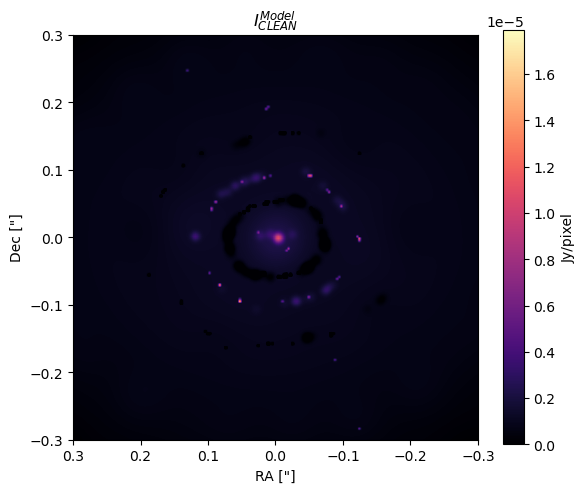

In [72]:
plt.figure(figsize=(6,5))
norm = colors.PowerNorm(gamma=1, vmin=0, vmax = img.max())
ax = plt.gca()
im = ax.imshow(
    img,
    extent=[xmin, xmax, ymin, ymax],
    aspect='equal',
    cmap='magma',
    norm=norm,
)
ax.set_xlabel('RA ["]')
ax.set_ylabel('Dec ["]')
ax.set_title(r'$I^{Model}_{CLEAN}$')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(hdr.get('BUNIT', 'Intensity'))
plt.xlim(0.3, -0.3)
plt.ylim(-0.3, 0.3)
ax.grid(False)
plt.tight_layout()
plt.show()

In [73]:
# arcsecs per pixel
ra_off_arcsec[0][1] -ra_off_arcsec[0][0]

-0.0016000046066801943

In [74]:
# img comes without the beam convolutded
# I_clean_model =  np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis_model_c_grid))).real/(frank2d3.FT._dx * frank2d3.FT._dy)
vis_clean = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img)))

In [75]:
vis_clean.shape

(3000, 3000)

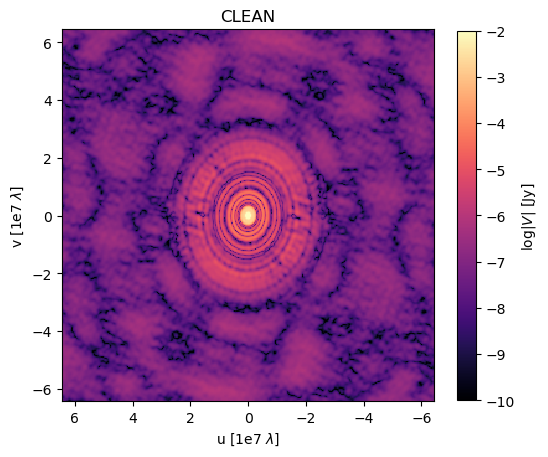

In [87]:
plt.figure(figsize = (6, 6))
plt.pcolormesh( u_f2d/1e6, v_f2d/1e6,
            np.log(np.abs(vis_clean.reshape(imsize, imsize))),
            cmap="magma",
            vmin=-10, vmax=-2)
plt.xlabel(r'u [1e7 $\lambda$]')
plt.ylabel(r'v [1e7 $\lambda$]')
plt.title("CLEAN")
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'log|$V$| [Jy]', size=10)
plt.xlim(u_f2d.max()/1e7, u_f2d.min()/1e7)
plt.ylim(v_f2d.min()/1e7, v_f2d.max()/1e7)
plt.gca().set_aspect(1)
plt.show()

### Difference

In [77]:
diff = (vis2d_f2d - vis_clean)

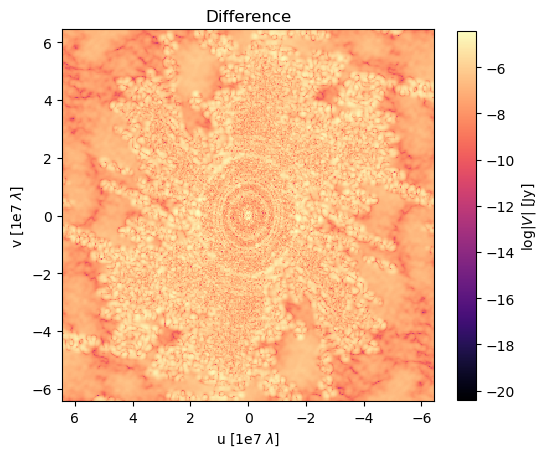

In [91]:
plt.figure(figsize = (6, 6))
plt.pcolormesh( u_f2d/1e6, v_f2d/1e6,
            np.log(np.abs((diff).reshape(imsize, imsize))),
            cmap="magma")
plt.xlabel(r'u [1e7 $\lambda$]')
plt.ylabel(r'v [1e7 $\lambda$]')
plt.title("Difference")
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'log|$V$| [Jy]', size=10)
plt.xlim(u_f2d.max()/1e7, u_f2d.min()/1e7)
plt.ylim(v_f2d.min()/1e7, v_f2d.max()/1e7)
plt.gca().set_aspect(1)
plt.show()

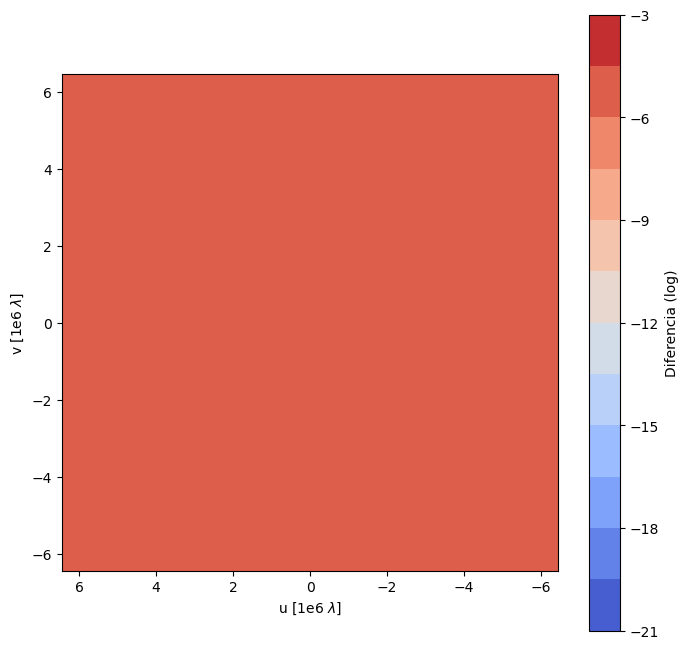

In [89]:

data_log = np.log(np.abs((diff).reshape(imsize, imsize)))

sigma_levels = [ -5*sigma, -3*sigma, 3*sigma, 5*sigma]
plt.figure(figsize=(8, 8))

plt.contourf(u_f2d, v_f2d, data_log, levels=10, cmap='coolwarm')
plt.colorbar(label='Diferencia (log)')

plt.contour(u_f2d, v_f2d, data_log, 
            levels=sigma_levels,
            colors='black', 
            linewidths=1.5)

plt.xlim(u_f2d.max()/1e7, u_f2d.min()/1e7)
plt.ylim(v_f2d.min()/1e7, v_f2d.max()/1e7)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.gca().set_aspect('equal', adjustable='box')
plt.show()